In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

data_ct = pd.read_csv("data/customer_support_tickets.csv")
data_ct.shape

(8469, 17)

In [4]:
data_ct[["Ticket Description", "Ticket Type"]].isna().sum()


Ticket Description    0
Ticket Type           0
dtype: int64

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29
Name: proportion, dtype: float64


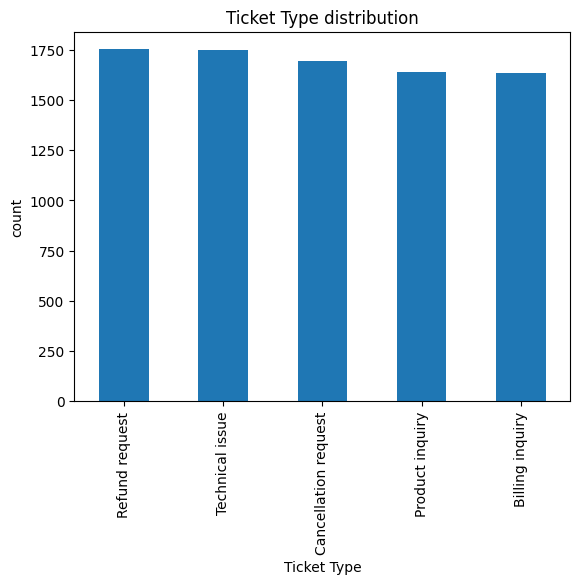

In [5]:
class_counts = data_ct["Ticket Type"].value_counts()
class_pct = data_ct["Ticket Type"].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

class_counts.plot(kind="bar", title="Ticket Type distribution")
plt.ylabel("count")
plt.show()


count    8469.000000
mean       46.467352
std         8.461730
min        21.000000
25%        43.000000
50%        49.000000
75%        52.000000
max        63.000000
Name: desc_word_count, dtype: float64


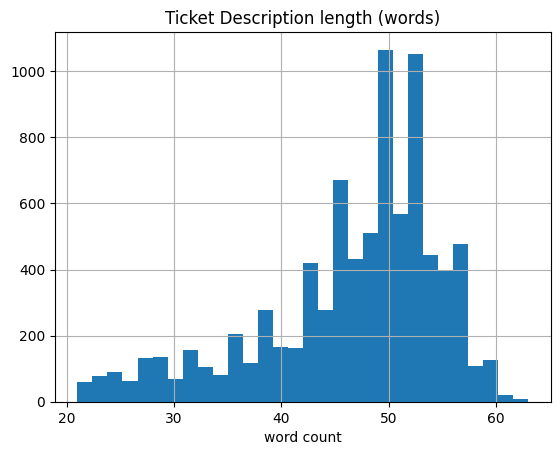

In [6]:
data_ct["desc_word_count"] = data_ct["Ticket Description"].str.split().str.len()
print(data_ct["desc_word_count"].describe())

data_ct["desc_word_count"].hist(bins=30)
plt.title("Ticket Description length (words)")
plt.xlabel("word count")
plt.show()

In [8]:
dupes = data_ct["Ticket Description"].duplicated().sum()
print(f"Duplicate descriptions: {dupes}")

Duplicate descriptions: 392


In [ ]:
for cat in data_ct["Ticket Type"].unique():
    print(f"\n=== {cat} ===")
    print(data_ct[data_ct["Ticket Type"] == cat]["Ticket Description"].sample(2, random_state=RANDOM_STATE).to_list())

In [9]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    stopwords = {"the","is","and","a","an","to","of","in","on","for","with","that",
                 "this","it","as","at","by","from","be","are","was","were","has",
                 "had","have","he","his","she","hers","him","her"}
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stopwords]
    return " ".join(words)

data_ct["preprocessed"] = data_ct["Ticket Description"].apply(clean_text)
data_ct[["Ticket Description", "preprocessed"]].head()

,Ticket Description,preprocessed
0,I'm having an issue with the {product_purchase...,im having issue productpurchased please assist...
1,I'm having an issue with the {product_purchase...,im having issue productpurchased please assist...
2,I'm facing a problem with my {product_purchase...,im facing problem my productpurchased productp...
3,I'm having an issue with the {product_purchase...,im having issue productpurchased please assist...
4,I'm having an issue with the {product_purchase...,im having issue productpurchased please assist...


In [10]:
X = data_ct["preprocessed"]
y = data_ct["Ticket Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, X_test.shape)

(5928,) (2541,)
